In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
shop=pd.read_csv("/content/shopping_trends_updated.csv.csv")

In [ ]:
shop.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
shop.dtypes#shop.info()

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [ ]:
shop.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [ ]:
shop.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
shop["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
shop["Category"].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [ ]:
shop["Size"].unique()

array(['L', 'S', 'M', 'XL'], dtype=object)

In [ ]:
shop["Subscription Status"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
shop["Shipping Type"].unique()

array(['Express', 'Free Shipping', 'Next Day Air', 'Standard',
       '2-Day Shipping', 'Store Pickup'], dtype=object)

In [ ]:
shop["Discount Applied"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
shop["Promo Code Used"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
shop["Payment Method"].unique()

array(['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer',
       'Debit Card'], dtype=object)

In [ ]:
# what is the overall distribution of customer ages in dataset
shop["Age"].value_counts()

,count
Age,
69,88
57,87
41,86
25,85
49,84
54,83
27,83
50,83
62,83


In [ ]:
shop["Age"].mean()

np.float64(44.06846153846154)

In [ ]:
shop["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
shop["Age_category"]=pd.cut(shop["Age"],bins=[0,15,18,30,50,70],labels=["child","teen","Young Adults","Middle-Aged adults","old"])

In [ ]:
fig=px.histogram(shop,y="Age",x="Age_category")
fig.show()

In [ ]:
# How does the average purchase amount vary across diffrent product category
shop.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Age_category'],
      dtype='object')

In [ ]:
shop["Category"].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [ ]:
shop.groupby("Category")["Purchase Amount (USD)"].mean()

,Purchase Amount (USD)
Category,
Accessories,59.838710
Clothing,60.025331
Footwear,60.255426
Outerwear,57.172840


<Axes: xlabel='Gender', ylabel='Purchase Amount (USD)'>

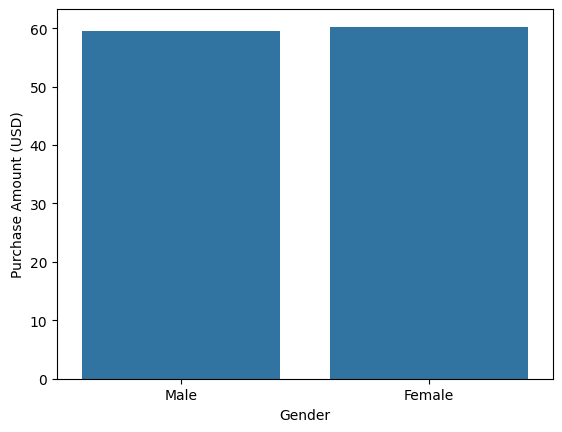

In [ ]:
# Which gender has the highest number of purchase
sns.barplot(shop,x="Gender",y="Purchase Amount (USD)",errorbar=None)

In [ ]:
# What are the most commonly purchased in items in each category
shop.groupby("Category")["Item Purchased"].value_counts()

Category     Item Purchased
Accessories  Jewelry           171
             Belt              161
             Sunglasses        161
             Scarf             157
             Hat               154
             Handbag           153
             Backpack          143
             Gloves            140
Clothing     Blouse            171
             Pants             171
             Shirt             169
             Dress             166
             Sweater           164
             Socks             159
             Skirt             158
             Shorts            157
             Hoodie            151
             T-shirt           147
             Jeans             124
Footwear     Sandals           160
             Shoes             150
             Sneakers          145
             Boots             144
Outerwear    Jacket            163
             Coat              161
Name: count, dtype: int64

In [ ]:
fig=px.histogram(shop,x="Item Purchased",color="Category")
fig.show()

In [ ]:
# Are three any specific seasons or months where customer spending is significantly higher
shop["Season"].unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

In [ ]:
shop[shop["Season"]=="Summer"].value_counts().sum()

np.int64(955)

In [ ]:
shop[shop["Season"]=="winter"].value_counts()

,,,,,,,,,,,,,,,,,,,count
Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_category,


In [ ]:
shop[shop["Season"]=="Spring"].value_counts()

,,,,,,,,,,,,,,,,,,,count
Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_category,
3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly,old,1
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-Aged adults,1
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adults,1
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-Aged adults,1
10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly,old,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,49,Male,Blouse,Clothing,28,Maryland,M,Red,Spring,3.7,Yes,Store Pickup,Yes,Yes,39,Debit Card,Bi-Weekly,Middle-Aged adults,1
50,68,Male,Hoodie,Clothing,30,New Jersey,S,Indigo,Spring,4.6,Yes,Next Day Air,Yes,Yes,34,Debit Card,Bi-Weekly,old,1
43,20,Male,Coat,Outerwear,100,Tennessee,M,Beige,Spring,4.1,Yes,Free Shipping,Yes,Yes,15,PayPal,Annually,Young Adults,1


In [ ]:
shop[shop["Season"]=="Fall"].value_counts()

,,,,,,,,,,,,,,,,,,,count
Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_category,
3894,21,Female,Hat,Accessories,64,Massachusetts,L,White,Fall,3.3,No,Store Pickup,No,No,29,Bank Transfer,Bi-Weekly,Young Adults,1
7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly,old,1
11,53,Male,Shoes,Footwear,34,Arkansas,L,Purple,Fall,4.1,Yes,Store Pickup,Yes,Yes,26,Bank Transfer,Bi-Weekly,old,1
25,18,Male,Jacket,Outerwear,22,Florida,M,Green,Fall,2.9,Yes,Store Pickup,Yes,Yes,16,Debit Card,Weekly,teen,1
29,54,Male,Handbag,Accessories,94,North Carolina,M,Gray,Fall,4.4,Yes,Free Shipping,Yes,Yes,41,PayPal,Every 3 Months,old,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,44,Male,Scarf,Accessories,39,Kentucky,L,Violet,Fall,3.7,Yes,Next Day Air,Yes,Yes,13,PayPal,Fortnightly,Middle-Aged adults,1
124,57,Male,Sweater,Clothing,89,Louisiana,L,Brown,Fall,3.1,Yes,Free Shipping,Yes,Yes,46,Cash,Weekly,old,1
120,38,Male,Coat,Outerwear,76,Wyoming,M,Orange,Fall,4.3,Yes,Express,Yes,Yes,44,Cash,Annually,Middle-Aged adults,1


In [ ]:
fig=px.histogram(shop,x="Season",range_y=[200,1500])
fig.show()

In [ ]:
# What is the average rating given by for each product category
shop_groupby=shop.groupby("Category")["Review Rating"].mean().reset_index()

In [ ]:
fig=px.bar(shop_groupby,x="Category",y="Review Rating")
fig.show()

In [ ]:
# Are there any natable diffrences in purchase behavior between subscribed and non- susbcribed customers
shop["Subscription Status"].unique()

array(['Yes', 'No'], dtype=object)

<Axes: xlabel='Subscription Status', ylabel='Purchase Amount (USD)'>

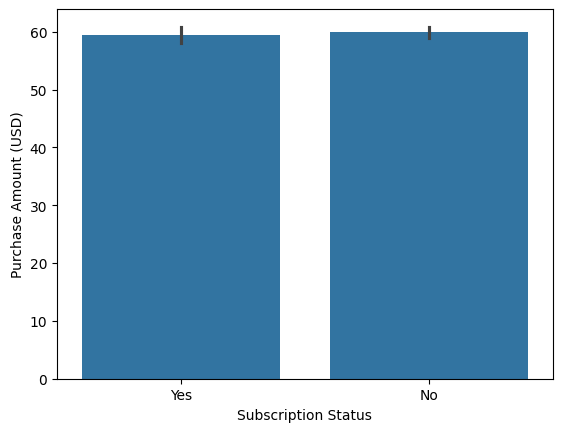

In [ ]:
sns.barplot(shop,x="Subscription Status",y="Purchase Amount (USD)")

In [ ]:
shop["Purchase Amount (USD)"].sum()

np.int64(233081)

In [ ]:
shop.groupby("Subscription Status")["Purchase Amount (USD)"].mean()

,Purchase Amount (USD)
Subscription Status,
No,59.865121
Yes,59.491928


In [ ]:
# Which payment method is the most popular among customer
shop.groupby("Payment Method")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

,Purchase Amount (USD)
Payment Method,
Debit Card,60.915094
Credit Card,60.074516
Bank Transfer,59.712418
Cash,59.704478
PayPal,59.245199
Venmo,58.949527


In [ ]:
shop_groupby=shop.groupby("Payment Method")["Purchase Amount (USD)"].mean().reset_index()

In [ ]:
shop_groupby

,Payment Method,Purchase Amount (USD)
0,Bank Transfer,59.712418
1,Cash,59.704478
2,Credit Card,60.074516
3,Debit Card,60.915094
4,PayPal,59.245199
5,Venmo,58.949527


In [ ]:
fig=px.bar(shop_groupby,x="Payment Method",y="Purchase Amount (USD)",color="Payment Method")
fig.show()

<Axes: xlabel='Payment Method', ylabel='Purchase Amount (USD)'>

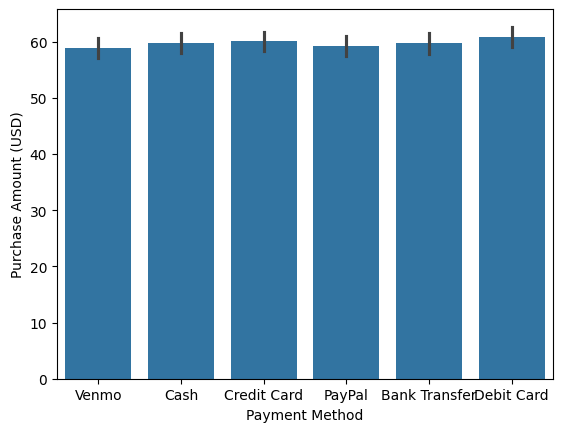

In [ ]:
sns.barplot(shop,x="Payment Method",y="Purchase Amount (USD)")

In [ ]:
# Do customers who use promo codes tends  to spend more those who don't
shop_groupby=shop.groupby("Promo Code Used")["Purchase Amount (USD)"].sum().reset_index()

In [ ]:
fig=px.sunburst(shop,path=["Gender","Promo Code Used"],values="Purchase Amount (USD)")
fig.show()

In [ ]:
fig=px.bar(shop_groupby,x="Promo Code Used",y="Purchase Amount (USD)")
fig.show()

In [ ]:
# 10 How does the frequency of purchase vary across diffrent age group
shop[["Age","Age_category"]]

,Age,Age_category
0,55,old
1,19,Young Adults
2,50,Middle-Aged adults
3,21,Young Adults
4,45,Middle-Aged adults
...,...,...
3895,40,Middle-Aged adults
3896,52,old
3897,46,Middle-Aged adults
3898,44,Middle-Aged adults


In [ ]:
shop["Age_category"].unique()

['old', 'Young Adults', 'Middle-Aged adults', 'teen']
Categories (5, object): ['child' < 'teen' < 'Young Adults' < 'Middle-Aged adults' < 'old']

In [ ]:
shop_group=shop.groupby("Frequency of Purchases")["Age"].sum()

In [ ]:
px.sunburst(shop,path=["Frequency of Purchases","Age_category"],values="Age")

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#Are they  any correlations between the size of product and the purchase amount
shop_group=shop.groupby("Size")["Purchase Amount (USD)"].sum().reset_index()

In [ ]:
fig=px.bar(shop_group,x="Size",y="Purchase Amount (USD)")
fig.show()

In [ ]:
#ehich shiping type is prefered by customer for diffrent product category
shop.groupby("Category")["Shipping Type"].value_counts().sort_values(ascending=False)

Category     Shipping Type 
Clothing     Standard          297
             Free Shipping     294
             Next Day Air      293
             Express           290
             Store Pickup      282
             2-Day Shipping    281
Accessories  Store Pickup      217
             Next Day Air      211
             Standard          208
             2-Day Shipping    206
             Express           203
             Free Shipping     195
Footwear     Free Shipping     122
             Standard          100
             Store Pickup       98
             Express            96
             Next Day Air       93
             2-Day Shipping     90
Outerwear    Free Shipping      64
             Express            57
             Store Pickup       53
             Next Day Air       51
             2-Day Shipping     50
             Standard           49
Name: count, dtype: int64

In [ ]:
shop["Shipping_Category"]=shop["Shipping Type"].map({"Express":0,"Free Shipping":1,"Next Day Air":2,"Standard":3,"2-Day Shipping":4,"Store Pickup":5})

In [ ]:
shop["Category"].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [ ]:
shop["Clothing_num"]=shop["Category"].map({"Clothing":1,"Footwear":2,"Outerwear":3,"Accessories":4})